In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import surprise
import joblib
import sklearn


In [7]:

user_rating_og = pd.read_csv('user-filtered.csv')
anime_info = pd.read_csv('anime-dataset-2023.csv')
user_info = pd.read_csv('users-details-2023.csv')

display(user_rating_og)
display(anime_info)
display(user_info)


,user_id,anime_id,rating
0,0,67,9
1,0,6702,7
2,0,242,10
3,0,4898,0
4,0,21,10
...,...,...,...
109224742,353404,507,7
109224743,353404,392,9
109224744,353404,882,6
109224745,353404,883,8


,anime_id,Name,English name,Other name,Score,Genres,Synopsis,Type,Episodes,Aired,...,Studios,Source,Duration,Rating,Rank,Popularity,Favorites,Scored By,Members,Image URL
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,8.75,"Action, Award Winning, Sci-Fi","Crime is timeless. By the year 2071, humanity ...",TV,26.0,"Apr 3, 1998 to Apr 24, 1999",...,Sunrise,Original,24 min per ep,R - 17+ (violence & profanity),41.0,43,78525,914193.0,1771505,https://cdn.myanimelist.net/images/anime/4/196...
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,8.38,"Action, Sci-Fi","Another day, another bounty—such is the life o...",Movie,1.0,"Sep 1, 2001",...,Bones,Original,1 hr 55 min,R - 17+ (violence & profanity),189.0,602,1448,206248.0,360978,https://cdn.myanimelist.net/images/anime/1439/...
2,6,Trigun,Trigun,トライガン,8.22,"Action, Adventure, Sci-Fi","Vash the Stampede is the man with a $$60,000,0...",TV,26.0,"Apr 1, 1998 to Sep 30, 1998",...,Madhouse,Manga,24 min per ep,PG-13 - Teens 13 or older,328.0,246,15035,356739.0,727252,https://cdn.myanimelist.net/images/anime/7/203...
3,7,Witch Hunter Robin,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),7.25,"Action, Drama, Mystery, Supernatural",Robin Sena is a powerful craft user drafted in...,TV,26.0,"Jul 3, 2002 to Dec 25, 2002",...,Sunrise,Original,25 min per ep,PG-13 - Teens 13 or older,2764.0,1795,613,42829.0,111931,https://cdn.myanimelist.net/images/anime/10/19...
4,8,Bouken Ou Beet,Beet the Vandel Buster,冒険王ビィト,6.94,"Adventure, Fantasy, Supernatural",It is the dark century and the people are suff...,TV,52.0,"Sep 30, 2004 to Sep 29, 2005",...,Toei Animation,Manga,23 min per ep,PG - Children,4240.0,5126,14,6413.0,15001,https://cdn.myanimelist.net/images/anime/7/215...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24900,55731,Wu Nao Monu,UNKNOWN,无脑魔女,UNKNOWN,"Comedy, Fantasy, Slice of Life",No description available for this anime.,ONA,15.0,"Jul 4, 2023 to ?",...,UNKNOWN,Web manga,Unknown,PG-13 - Teens 13 or older,UNKNOWN,24723,0,UNKNOWN,0,https://cdn.myanimelist.net/images/anime/1386/...
24901,55732,Bu Xing Si: Yuan Qi,Blader Soul,捕星司·源起,UNKNOWN,"Action, Adventure, Fantasy",No description available for this anime.,ONA,18.0,"Jul 27, 2023 to ?",...,UNKNOWN,Web novel,Unknown,PG-13 - Teens 13 or older,0.0,0,0,UNKNOWN,0,https://cdn.myanimelist.net/images/anime/1383/...
24902,55733,Di Yi Xulie,The First Order,第一序列,UNKNOWN,"Action, Adventure, Fantasy, Sci-Fi",No description available for this anime.,ONA,16.0,"Jul 19, 2023 to ?",...,UNKNOWN,Web novel,Unknown,PG-13 - Teens 13 or older,0.0,0,0,UNKNOWN,0,https://cdn.myanimelist.net/images/anime/1130/...
24903,55734,Bokura no Saishuu Sensou,UNKNOWN,僕らの最終戦争,UNKNOWN,UNKNOWN,A music video for the song Bokura no Saishuu S...,Music,1.0,"Apr 23, 2022",...,UNKNOWN,Original,3 min,PG-13 - Teens 13 or older,0.0,0,0,UNKNOWN,0,https://cdn.myanimelist.net/images/anime/1931/...


,Mal ID,Username,Gender,Birthday,Location,Joined,Days Watched,Mean Score,Watching,Completed,On Hold,Dropped,Plan to Watch,Total Entries,Rewatched,Episodes Watched
0,1,Xinil,Male,1985-03-04T00:00:00+00:00,California,2004-11-05T00:00:00+00:00,142.3,7.37,1.0,233.0,8.0,93.0,64.0,399.0,60.0,8458.0
1,3,Aokaado,Male,NaN,"Oslo, Norway",2004-11-11T00:00:00+00:00,68.6,7.34,23.0,137.0,99.0,44.0,40.0,343.0,15.0,4072.0
2,4,Crystal,Female,NaN,"Melbourne, Australia",2004-11-13T00:00:00+00:00,212.8,6.68,16.0,636.0,303.0,0.0,45.0,1000.0,10.0,12781.0
3,9,Arcane,NaN,NaN,NaN,2004-12-05T00:00:00+00:00,30.0,7.71,5.0,54.0,4.0,3.0,0.0,66.0,0.0,1817.0
4,18,Mad,NaN,NaN,NaN,2005-01-03T00:00:00+00:00,52.0,6.27,1.0,114.0,10.0,5.0,23.0,153.0,42.0,3038.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
731285,1291083,Dolopa,NaN,NaN,NaN,2012-05-06T00:00:00+00:00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
731286,1291085,alenrobnik,NaN,NaN,NaN,2012-05-06T00:00:00+00:00,21.4,8.22,16.0,58.0,9.0,1.0,42.0,126.0,0.0,1239.0
731287,1291087,Oblongata,NaN,1993-01-30T00:00:00+00:00,NaN,2012-05-06T00:00:00+00:00,51.3,7.53,38.0,175.0,0.0,9.0,211.0,433.0,2.0,3010.0
731288,1291091,Etnota,NaN,NaN,NaN,2012-05-06T00:00:00+00:00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [44]:

user_rating = user_rating_og

animes = user_rating['anime_id'].unique()


In [ ]:
display(user_rating.dtypes)
display(user_rating['rating'].unique())
display(user_rating.describe())
display(animes)

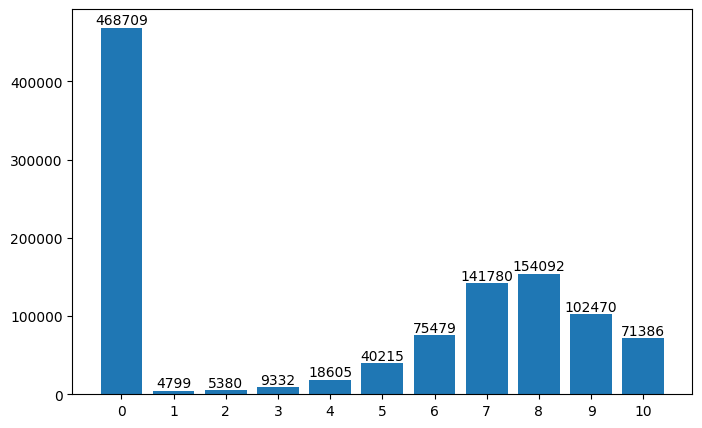

In [6]:

fig, ax = plt.subplots(figsize = (8, 5))

a = ax.bar(user_rating['rating'].value_counts().index, 
       user_rating['rating'].value_counts().values)

ax.bar_label(a, user_rating['rating'].value_counts().values.astype(int))
ax.set_xticks(range(0, 11))

plt.show()

In [181]:
user_rating = user_rating.replace({0 : np.nan})
user_rating = user_rating.dropna()

user_rating['user_id'] = user_rating['user_id'].astype(np.int32)
user_rating['anime_id'] = user_rating['anime_id'].astype(np.int32)
user_rating['rating'] = user_rating['rating'].astype(np.int16)

user_rating = user_rating.drop_duplicates(subset=['user_id', 'anime_id'])
user_rating = user_rating.dropna(subset=['rating'])

anime_info['Name'] = anime_info['Name'].str.lower()

mean_score = anime_info[anime_info['Score'] != 'UNKNOWN']['Score'].astype(float).mean()

anime_info['Score'] = anime_info['Score'].replace('UNKNOWN', mean_score)
anime_info['Score'] = anime_info['Score'].astype(float)

user_rating


,user_id,anime_id,rating
74,1,37403,8
77,1,7674,7
79,1,34566,7
81,1,40852,9
82,1,10087,7
...,...,...,...
109224741,353404,243,7
109224742,353404,507,7
109224743,353404,392,9
109224744,353404,882,6


In [5]:

reader = surprise.Reader(rating_scale = (0, 10))

surprise_data = surprise.Dataset.load_from_df(
    user_rating[['user_id', 'anime_id', 'rating']], 
    reader
)

train, test = surprise.model_selection.train_test_split(
    surprise_data,
    test_size = 0.2,
    random_state = 1
)

In [39]:

params = {
    'n_factors': [50, 100, 150],
    'n_epochs': [20, 30, 40],
    'lr_all': [0.003, 0.005, 0.01],
    'reg_all': [0.01, 0.02, 0.05]
}

gs = surprise.model_selection.RandomizedSearchCV(
    surprise.SVD, 
    params, 
    measures=['rmse'],
    n_iter = 20, 
    cv=3,
    n_jobs=-1,
    joblib_verbose=1
)
    
gs.fit(surprise_data)
    
best_params = gs.best_params['rmse']


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:   44.9s
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:  1.8min finished


In [8]:

anime_model = surprise.SVD(**{'n_factors': 150, 'n_epochs': 40, 'lr_all': 0.01, 'reg_all': 0.05}, verbose = 2)
anime_model.fit(train)

predicted = anime_model.test(test)

print(f'RMSE: {surprise.accuracy.rmse(predicted, verbose=False)}')
print(f'MAE: {surprise.accuracy.mae(predicted, verbose=False)}')


Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
Processing epoch 20
Processing epoch 21
Processing epoch 22
Processing epoch 23
Processing epoch 24
Processing epoch 25
Processing epoch 26
Processing epoch 27
Processing epoch 28
Processing epoch 29
Processing epoch 30
Processing epoch 31
Processing epoch 32
Processing epoch 33
Processing epoch 34
Processing epoch 35
Processing epoch 36
Processing epoch 37
Processing epoch 38
Processing epoch 39
RMSE: 1.1807662569809865
MAE: 0.8702800999116374


In [10]:
joblib.dump(anime_model, 'anime_model.pkl')

['anime_model.pkl']

In [5]:

anime_info = pd.read_csv('anime-dataset-2023.csv')
user_info = pd.read_csv('users-details-2023.csv')

anime_model = joblib.load('anime_model.pkl')


In [121]:
user_rating[user_rating['user_id'] == 1]

,user_id,anime_id,rating
74,1,37403,8
77,1,7674,7
79,1,34566,7
81,1,40852,9
82,1,10087,7
...,...,...,...
196,1,23847,8
197,1,33161,8
198,1,37779,9
199,1,35507,7


In [158]:

user_rating_filtered = user_rating[user_rating['rating'] >= 7]

user_rating_anime_info = user_rating_filtered.merge(anime_info[['anime_id', 'Name']], on = 'anime_id', how = 'left')
user_rating_anime_info = user_rating_anime_info.dropna()

animes_watched = user_rating_anime_info.groupby('user_id')['Name'].apply(list).to_frame().reset_index()
animes_watched_str = animes_watched['Name'].apply(lambda x : ' '.join(x)).tolist()

tfidf_anime = sklearn.feature_extraction.text.TfidfVectorizer(stop_words='english')
anime_matrix = tfidf_anime.fit_transform(animes_watched_str)


In [211]:

def get_recommended(seen_anime, how_many = 5):

    seen_anime = [name.lower() for name in seen_anime]
    seen_anime_str = ' '.join([name.strip() for name in seen_anime])
    seen_anime_tfidf = tfidf_anime.transform([seen_anime_str])

    similarities = sklearn.metrics.pairwise.cosine_similarity(seen_anime_tfidf, anime_matrix).flatten()

    most_simular_user_indice = similarities.argsort()[::-1][:1]
    most_sumuler_user = animes_watched.iloc[most_simular_user_indice][['user_id', 'Name']].copy()

    seen_anime_ids = pd.merge(left = pd.DataFrame(seen_anime, columns = ['Name']), right = anime_info, on = 'Name', how = 'left')['anime_id']
    
    animes_by_user_preference = pd.DataFrame()
    animes_by_user_preference['anime_id'] = pd.Series(list(set(animes) - set(seen_anime_ids)))

    animes_by_user_preference['predicted_rating'] = animes_by_user_preference['anime_id'].apply(
        lambda anime : anime_model.predict(most_sumuler_user['user_id'].values[0], anime).est
    ) 

    final_recommendation = pd.merge(left = animes_by_user_preference, right = anime_info, on = 'anime_id', how = 'left').sort_values(by = ['predicted_rating'], ascending = False).head(how_many)
    final_recommendation = final_recommendation[['Name', 'Synopsis', 'Score', 'Genres', 'Rating', 'Type', 'Episodes', 'Aired', 'Status', 'Studios', 'Source', 'Duration', 'predicted_rating']]

    return final_recommendation


In [217]:
animes_watched[animes_watched['user_id'] == 4334]['Name'].values[0]

['jujutsu kaisen',
 'ano hi mita hana no namae wo bokutachi wa mada shiranai.',
 'barakamon',
 'black lagoon',
 'black lagoon: the second barrage',
 'blend s',
 'boku no hero academia the movie 1: futari no hero',
 'byousoku 5 centimeter',
 'cowboy bebop',
 'cross game',
 'danna ga nani wo itteiru ka wakaranai ken',
 'danna ga nani wo itteiru ka wakaranai ken 2 sure-me',
 'dareka no manazashi',
 'devilman: crybaby',
 'evangelion: 1.0 you are (not) alone',
 'evangelion: 2.0 you can (not) advance',
 'evangelion: 3.0 you can (not) redo',
 'furiko',
 'hinamatsuri (tv)',
 'hunter x hunter (2011)',
 'jin-rou',
 'k-on!',
 'k-on!!',
 'katanagatari',
 'kemonozume',
 'kenpuu denki berserk',
 'kill la kill',
 'kimetsu no yaiba',
 'kimi no na wa.',
 'koe no katachi',
 'kono sekai no katasumi ni',
 'kono subarashii sekai ni shukufuku wo!',
 'kono subarashii sekai ni shukufuku wo! 2',
 'kotonoha no niwa',
 'koukaku kidoutai',
 'kyousou giga (tv)',
 'little witch academia',
 'made in abyss',
 'made i

In [220]:
get_recommended([
    'one piece',
    'dragon ball z',
    'cowboy bebop',
])

,Name,Synopsis,Score,Genres,Rating,Type,Episodes,Aired,Status,Studios,Source,Duration,predicted_rating
9883,koe no katachi,"As a wild youth, elementary school student Sho...",8.94,"Award Winning, Drama",PG-13 - Teens 13 or older,Movie,1.0,"Sep 17, 2016",Finished Airing,Kyoto Animation,Manga,2 hr 10 min,9.269005
6471,hunter x hunter (2011),Hunters devote themselves to accomplishing haz...,9.04,"Action, Adventure, Fantasy",PG-13 - Teens 13 or older,TV,148.0,"Oct 2, 2011 to Sep 24, 2014",Finished Airing,Madhouse,Manga,23 min per ep,9.254660
6730,ookami kodomo no ame to yuki,"Hana, a hard-working college student, falls in...",8.58,"Award Winning, Fantasy, Slice of Life",PG-13 - Teens 13 or older,Movie,1.0,"Jul 21, 2012",Finished Airing,Studio Chizu,Original,1 hr 57 min,9.182350
3534,clannad: after story,"Clannad: After Story, the sequel to the critic...",8.93,"Drama, Romance, Supernatural",PG-13 - Teens 13 or older,TV,24.0,"Oct 3, 2008 to Mar 27, 2009",Finished Airing,Kyoto Animation,Visual novel,24 min per ep,9.139584
402,howl no ugoku shiro,"That jumbled piece of architecture, that cacop...",8.66,"Adventure, Award Winning, Drama, Fantasy, Romance",G - All Ages,Movie,1.0,"Nov 20, 2004",Finished Airing,Studio Ghibli,Novel,1 hr 59 min,9.136329
